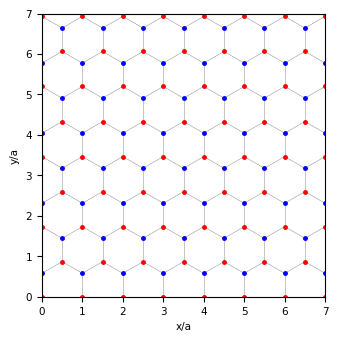

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Global style
fs = 7.5
plt.rcParams.update({
    "font.size": fs,
    "axes.labelsize": fs,
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
})

# Geometry: nearest-neighbor distance
d = 1.0 / np.sqrt(3.0)

# Graphene Bravais vectors (in units where lattice constant a = 1)
a1 = np.array([np.sqrt(3) * d, 0.0])          # [1, 0]
a2 = np.array([np.sqrt(3) * d / 2.0, 1.5 * d]) # [1/2, sqrt(3)/2]

# Sublattice offset A -> B
delta = np.array([0.0, d])

# Three nearest-neighbor vectors from A to B
nn = [
    np.array([0.0, d]),
    np.array([-np.sqrt(3) * d / 2.0, -d / 2.0]),
    np.array([ np.sqrt(3) * d / 2.0, -d / 2.0]),
]

# Plot window in x,y coordinates
xmin, xmax = 0.0, 7.0
ymin, ymax = 0.0, 7.0

# Build a sufficiently large lattice, then crop
A_sites = []
B_sites = []
for n in range(-20, 40):
    for m in range(-20, 40):
        rA = n * a1 + m * a2
        rB = rA + delta
        A_sites.append(rA)
        B_sites.append(rB)

A_sites = np.array(A_sites)
B_sites = np.array(B_sites)

# Keep points inside the 7x7 window
maskA = (
    (A_sites[:, 0] >= xmin) & (A_sites[:, 0] <= xmax) &
    (A_sites[:, 1] >= ymin) & (A_sites[:, 1] <= ymax)
)
maskB = (
    (B_sites[:, 0] >= xmin) & (B_sites[:, 0] <= xmax) &
    (B_sites[:, 1] >= ymin) & (B_sites[:, 1] <= ymax)
)

A_in = A_sites[maskA]
B_in = B_sites[maskB]

# Fast lookup for B sites (for bond drawing)
def key(p, nd=10):
    return (round(float(p[0]), nd), round(float(p[1]), nd))

B_set = {key(p) for p in B_sites}

fig, ax = plt.subplots(figsize=(3.45, 3.45))

# Draw nearest-neighbor bonds using matplotlib only
for rA in A_in:
    for dv in nn:
        rB = rA + dv
        if key(rB) in B_set:
            if (xmin <= rB[0] <= xmax) and (ymin <= rB[1] <= ymax):
                ax.plot([rA[0], rB[0]], [rA[1], rB[1]], color="0.6", lw=0.4, zorder=1)

# Draw sublattices
ax.plot(A_in[:, 0], A_in[:, 1], "o", color="red",  markersize=2.5, zorder=2)
ax.plot(B_in[:, 0], B_in[:, 1], "o", color="blue", markersize=2.5, zorder=2)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("x/a")
ax.set_ylabel("y/a")
ax.set_aspect(1)

plt.tight_layout()
plt.show()


## Plotting 3D system with light irradiation

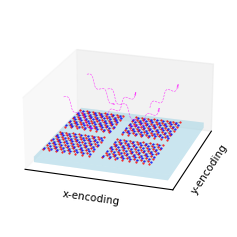

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fs = 7.5
plt.rcParams.update({
    'font.size': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
})

fig = plt.figure(figsize=(3.45, 2.4))
ax = fig.add_subplot(111, projection='3d')
ax.computed_zorder = False

# 1) Bottom object: light-blue substrate block, 20x20 in x-y, z thickness 0.5 at z=-1.
x0, x1 = -10.0, 10.0
y0, y1 = -10.0, 10.0
z0, z1 = -1.0, -0.5
verts = [
    [(x0, y0, z0), (x1, y0, z0), (x1, y1, z0), (x0, y1, z0)],
    [(x0, y0, z1), (x1, y0, z1), (x1, y1, z1), (x0, y1, z1)],
    [(x0, y0, z0), (x1, y0, z0), (x1, y0, z1), (x0, y0, z1)],
    [(x0, y1, z0), (x1, y1, z0), (x1, y1, z1), (x0, y1, z1)],
    [(x0, y0, z0), (x0, y1, z0), (x0, y1, z1), (x0, y0, z1)],
    [(x1, y0, z0), (x1, y1, z0), (x1, y1, z1), (x1, y0, z1)],
]
block = Poly3DCollection(verts, facecolors='lightblue', alpha=0.4, edgecolors='none')
block.set_zorder(1)
ax.add_collection3d(block)

# 2) Middle object: graphene (from first-cell logic), converted to 3D at z=0.
d = 1.0 / np.sqrt(3.0)
a1 = np.array([np.sqrt(3) * d, 0.0])
a2 = np.array([np.sqrt(3) * d / 2.0, 1.5 * d])
delta = np.array([0.0, d])
nn = [
    np.array([0.0, d]),
    np.array([-np.sqrt(3) * d / 2.0, -d / 2.0]),
    np.array([ np.sqrt(3) * d / 2.0, -d / 2.0]),
]

xmin, xmax = 0.0, 7.0
ymin, ymax = 0.0, 7.0
A_sites, B_sites = [], []
for n in range(-20, 40):
    for m in range(-20, 40):
        rA = n * a1 + m * a2
        rB = rA + delta
        A_sites.append(rA)
        B_sites.append(rB)
A_sites = np.array(A_sites)
B_sites = np.array(B_sites)

def key(p, nd=10):
    return (round(float(p[0]), nd), round(float(p[1]), nd))

B_set = {key(p) for p in B_sites}
maskA = (A_sites[:, 0] >= xmin) & (A_sites[:, 0] <= xmax) & (A_sites[:, 1] >= ymin) & (A_sites[:, 1] <= ymax)
maskB = (B_sites[:, 0] >= xmin) & (B_sites[:, 0] <= xmax) & (B_sites[:, 1] >= ymin) & (B_sites[:, 1] <= ymax)
A_in = A_sites[maskA]
B_in = B_sites[maskB]

# Place 4 graphene pieces: each 7x7, spacing 2 between pieces/edges (same layout as before).
tile_size = 7.0
gap = 2.0
start = -9.0
tile_origins = [(start + i * (tile_size + gap), start + j * (tile_size + gap)) for i in range(2) for j in range(2)]

for ox, oy in tile_origins:
    for rA in A_in:
        for dv in nn:
            rB = rA + dv
            if key(rB) in B_set and (xmin <= rB[0] <= xmax) and (ymin <= rB[1] <= ymax):
                ax.plot([ox + rA[0], ox + rB[0]], [oy + rA[1], oy + rB[1]], [0.0, 0.0], color='0.55', lw=0.35, zorder=10)

    ax.plot(ox + A_in[:, 0], oy + A_in[:, 1], np.zeros(len(A_in)), 'o', color='red', 
            markersize=0.5, zorder=11)
    ax.plot(ox + B_in[:, 0], oy + B_in[:, 1], np.zeros(len(B_in)), 'o', color='blue', 
            markersize=0.5, zorder=11)

# 3) Top object: red tilted sinusoidal lines with larger arrowheads.
def wavy_arrow(xc, yc, zc=3.2, length=5.0, amp=0.35, 
               npts=220, angle_deg=45.0, arrow_at='lower', color='darkgray', lw=0.433):
    t = np.linspace(-0.5, 0.5, npts)
    x = length * t
    z = amp * np.sin(4.0 * np.pi * t)
    ang = np.deg2rad(angle_deg)
    xr = x * np.cos(ang) - z * np.sin(ang)
    zr = x * np.sin(ang) + z * np.cos(ang)
    X = xc + xr
    Y = np.full_like(X, yc)
    Z = zc + zr
    ax.plot(X, Y, Z, color=color, lw=lw, alpha=0.7, linestyle='--', zorder=30)

    idx = np.argmin(Z) if arrow_at == 'lower' else np.argmax(Z)
    if idx == 0:
        j = 1
    elif idx == npts - 1:
        j = npts - 2
    else:
        left = idx - 1
        right = idx + 1
        if arrow_at == 'lower':
            # For lower end, point from higher-z neighbor toward the endpoint.
            j = left if Z[left] > Z[right] else right
        else:
            # For upper end, point from lower-z neighbor toward the endpoint.
            j = left if Z[left] < Z[right] else right

    dx = X[idx] - X[j]
    dy = Y[idx] - Y[j]
    dz = Z[idx] - Z[j]
    # Larger arrowheads relative to line width.
    vnorm = np.sqrt(dx**2 + dy**2 + dz**2) + 1e-12
    ux, uy, uz = dx / vnorm, dy / vnorm, dz / vnorm
    if arrow_at == 'lower':
        # Place arrow tip ~0.5 units beyond the lower endpoint along arrow direction.
        tip_x = X[idx] + 0.5 * ux
        tip_y = Y[idx] + 0.5 * uy
        tip_z = Z[idx] + 0.5 * uz
        ax.quiver(tip_x, tip_y, tip_z, dx, dy, dz, color=color, linewidth=lw, alpha=0.7,
                  arrow_length_ratio=11.5, pivot='tip', zorder=31)
    else:
        ax.quiver(X[j], Y[j], Z[j], dx, dy, dz, color=color, linewidth=lw, alpha=0.7,
                  arrow_length_ratio=11.5, zorder=31)
incoming = [(-5.0, -5.0), (0.0, 0.0), (-5.0, 5.0)]
for xc, yc in incoming:
    wavy_arrow(xc=xc, yc=yc, zc=2.8, angle_deg=-30.0, arrow_at='lower', color='magenta')

outgoing = [(5.0, -5.0), (0.0, 0.0), (5.0, 5.0)]
for xc, yc in outgoing:
    wavy_arrow(xc=xc, yc=yc, zc=2.8, angle_deg=30.0, arrow_at='upper', color='magenta')

ax.set_xlim(-11, 11)
ax.set_ylim(-11, 11)
ax.set_zlim(-1.5, 5.0)
ax.set_xlabel('x-encoding', labelpad=-10)
ax.set_ylabel('y-encoding', labelpad=-12)
ax.set_zlabel('')
ax.set_box_aspect((1, 1, 0.5))
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.zaxis.line.set_linewidth(0.0)
ax.zaxis.pane.set_alpha(0.0)
ax.view_init(elev=22, azim=-72)

# Remove grid lines from all axes.
ax.grid(False)
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis._axinfo['grid']['linewidth'] = 0

plt.tight_layout()
plt.savefig('graphene_3d_encoding.pdf', dpi=300, bbox_inches='tight')
plt.show()
